# MLP for MNIST

## Imports

In [4]:
import sys
import os
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [5]:
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import torch.nn.functional as F
from torch.optim import Adam

from src.data.dataset import get_mnist_dataloader
from src.models.mlp import FlowMatchingMLP
from src.flow.matching import OptimalTransportFlowMatcher

## Training

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

model = FlowMatchingMLP().to(device)
optimizer = Adam(model.parameters(), lr=1e-4)
flow_matcher = OptimalTransportFlowMatcher()

dataloader = get_mnist_dataloader(batch_size=64, is_train=True)
single_batch = next(iter(dataloader))[0].to(device)

Device: mps


In [8]:
epochs = 250

model.train()
history_loss = []

print("Start Training.")
for epoch in range(epochs):
    epoch_loss = 0.0
        
    for batch in dataloader:
        x1 = batch[0].to(device)
        x0 = torch.randn_like(x1)
        
        t, x_t, v_t = flow_matcher.sample_location_and_target(x0, x1)
        v_pred = model(x_t, t)
        
        loss = F.mse_loss(v_pred, v_t)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        current_loss = loss.item()
        epoch_loss += current_loss
        
    avg_epoch_loss = epoch_loss / len(dataloader)
    history_loss.append(avg_epoch_loss)
    print(f"--> Epoch {epoch+1} over. Mean Loss : {avg_epoch_loss:.4f}")

Start Training.
--> Epoch 1 over. Mean Loss : 1.2366
--> Epoch 2 over. Mean Loss : 1.1747
--> Epoch 3 over. Mean Loss : 1.1470
--> Epoch 4 over. Mean Loss : 1.0993
--> Epoch 5 over. Mean Loss : 1.0576
--> Epoch 6 over. Mean Loss : 1.0254
--> Epoch 7 over. Mean Loss : 0.9989
--> Epoch 8 over. Mean Loss : 0.9761
--> Epoch 9 over. Mean Loss : 0.9575
--> Epoch 10 over. Mean Loss : 0.9413
--> Epoch 11 over. Mean Loss : 0.9273
--> Epoch 12 over. Mean Loss : 0.9129
--> Epoch 13 over. Mean Loss : 0.9010
--> Epoch 14 over. Mean Loss : 0.8888
--> Epoch 15 over. Mean Loss : 0.8783
--> Epoch 16 over. Mean Loss : 0.8671
--> Epoch 17 over. Mean Loss : 0.8591
--> Epoch 18 over. Mean Loss : 0.8504
--> Epoch 19 over. Mean Loss : 0.8422
--> Epoch 20 over. Mean Loss : 0.8352
--> Epoch 21 over. Mean Loss : 0.8267
--> Epoch 22 over. Mean Loss : 0.8214
--> Epoch 23 over. Mean Loss : 0.8146
--> Epoch 24 over. Mean Loss : 0.8080
--> Epoch 25 over. Mean Loss : 0.8027
--> Epoch 26 over. Mean Loss : 0.7962
--> E

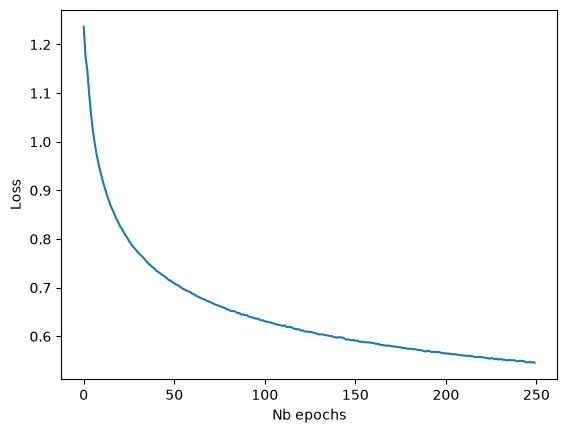

In [11]:
plt.figure()
plt.plot(history_loss)
plt.xlabel("Nb epochs")
plt.ylabel("Loss")
plt.show()

The model struggles to learn, it barely reach a Loss of 0.5.

In [13]:
torch.save(model.state_dict(), "../artefacts/00_mnist_mlp.pt")

## Results

To generate some images, we will just apply this formula:

$$x_{t+\Delta t} = x_t + v_{pred, t} \times \Delta t$$
- $x_t$: position at time t
- $v_{pred, t}$: predicted velocity
- $\Delta t$: time step

In [14]:
model.eval()

num_samples = 8
steps = 100
dt = 1.0 / steps

x_gen = torch.randn(num_samples, 1, 28, 28).to(device)

with torch.no_grad():
    for step in range(steps):
        t_val = step * dt
        t_tensor = torch.full((num_samples,), t_val, device=device)
        
        v_pred = model(x_gen, t_tensor)
        
        x_gen = x_gen + v_pred * dt

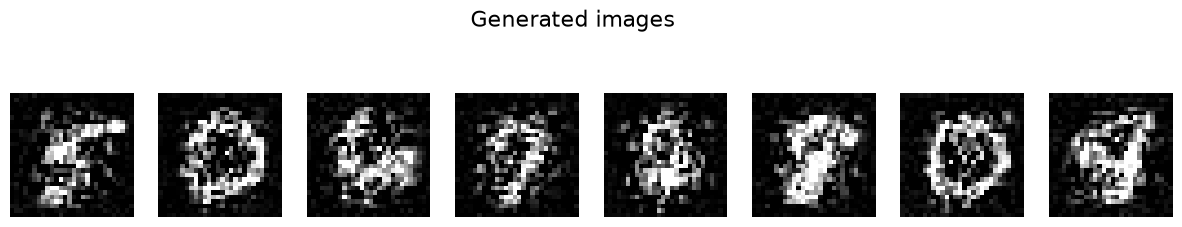

In [15]:
x_gen = x_gen.cpu().clamp(-1, 1)

fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
for i in range(num_samples):
    img = (x_gen[i, 0] + 1) / 2 
    axes[i].imshow(img.numpy(), cmap="gray")
    axes[i].axis("off")

plt.suptitle("Generated images", fontsize=16)
plt.show()

The results are not convincing. 